In [5]:
from google.colab import drive
drive.mount('/content/drive')

SAVE_ROOT = "/content/drive/MyDrive/maxrl_gsm8k"
os.makedirs(SAVE_ROOT, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:

!pip install -q swig
!pip install -q torch numpy matplotlib pandas tqdm
!pip install -q transformers datasets accelerate sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 87.5 MB/s eta 0:00:00


In [16]:
import re
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


import torch
import torch.nn as nn
import torch.optim as optim

import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset

In [33]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_NAME = "distilgpt2"
DATASET_NAME = "gsm8k"
DATASET_CONFIG = "main"

N_ITERS = 200
BATCH_SIZE = 8
NUM_SAMPLES_PER_PROMPT = 8
MAX_NEW_TOKENS = 64

LR = 1e-5
ENTROPY_COEF = 5e-5
SEED = 0

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Data Load

In [7]:
dataset = load_dataset(DATASET_NAME, DATASET_CONFIG)
train_data = dataset["train"]

print(train_data[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

{'question': 'Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?', 'answer': 'Natalia sold 48/2 = <<48/2=24>>24 clips in May.\nNatalia sold 48+24 = <<48+24=72>>72 clips altogether in April and May.\n#### 72'}


# Answer Extraction

In [36]:
def extract_gold_answer(answer_text):
    match = re.search(r"####\s*([-+]?\d+(?:\.\d+)?)", answer_text.replace(",", ""))
    if match:
        return match.group(1)
    return None


def extract_model_answer(text):
    text = text.replace(",", "")
    numbers = re.findall(r"[-+]?\d+(?:\.\d+)?", text)
    if len(numbers) == 0:
        return None
    return numbers[-1]


def is_correct(pred, gold):
    if pred is None or gold is None:
        return False
    try:
        return abs(float(pred) - float(gold)) < 1e-6
    except:
        return False

# model/Tokenizer

In [37]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(DEVICE)
model.train()

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# Prompt formatting

In [38]:
def make_prompt(question):
    return (
        "Solve the following math problem. "
        "Give the final answer as a number.\n\n"
        f"Question: {question}\n"
        "Answer:"
    )

# Generation+Logprob

In [55]:
def closeness_reward(pred_answer, gold_answer):
    try:
        if pred_answer is None or gold_answer is None:
            return 0.0
        pred_val = float(pred_answer)
        gold_val = float(gold_answer)
        return max(
            0.0,
            1.0 - abs(pred_val - gold_val) / (abs(gold_val) + 1.0)
        )
    except:
        return 0.0

In [56]:
def generate_and_score(prompt, gold_answer):
    input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(DEVICE)
    prompt_len = input_ids.shape[1]

    with torch.no_grad():
        generated = model.generate(
            input_ids=input_ids,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=True,
            temperature=1.0,
            top_p=0.95,
            pad_token_id=tokenizer.eos_token_id,
        )

    full_text = tokenizer.decode(generated[0], skip_special_tokens=True)
    gen_text = tokenizer.decode(generated[0][prompt_len:], skip_special_tokens=True)

    pred_answer = extract_model_answer(gen_text)
    correct = is_correct(pred_answer, gold_answer)

    reward = 0.0
    if pred_answer is not None:
        reward += 0.05

    reward += 0.3 * closeness_reward(pred_answer, gold_answer)

    if correct:
        reward += 1.0


    # logprob recomputation WITH gradient
    outputs = model(generated)
    logits = outputs.logits[:, :-1, :]
    labels = generated[:, 1:]

    log_probs = F.log_softmax(logits, dim=-1)
    token_log_probs = log_probs.gather(-1, labels.unsqueeze(-1)).squeeze(-1)

    # only generated tokens, not prompt tokens
    gen_token_log_probs = token_log_probs[:, prompt_len-1:]
    log_prob_sum = gen_token_log_probs.sum()

    # entropy for generated tokens
    probs = torch.softmax(logits[:, prompt_len-1:, :], dim=-1)
    log_probs_gen = F.log_softmax(logits[:, prompt_len-1:, :], dim=-1)
    entropy = -(probs * log_probs_gen).sum(dim=-1).sum()

    return {
        "prompt": prompt,
        "generation": gen_text,
        "gold": gold_answer,
        "pred": pred_answer,
        "reward": reward,
        "success": float(correct),
        "log_prob_sum": log_prob_sum,
        "entropy": entropy,
    }

# Weight

In [57]:
def compute_weights(returns, successes, method):
    """
    returns: torch.Tensor, shape (B,)
    successes: torch.Tensor, shape (B,)
    """

    if method == "reinforce":
        # Standard REINFORCE: absolute return weighting
        weights = returns

    elif method == "binary_maxrl":
        # Binary MaxRL: only successful trajectories are used
        K = successes.sum()
        if K.item() > 0:
            weights = successes / (K + 1e-8)
        else:
            weights = torch.zeros_like(successes)

    elif method == "continuous_maxrl":
        # Continuous MaxRL: reward-mass normalization
        R = returns.clone()

        # shift to nonnegative
        R = R - R.min()
        R = torch.clamp(R, min=0.0)

        denom = R.sum() + 1e-8
        weights = R / denom

    else:
        raise ValueError(f"Unknown method: {method}")

    return weights

# train

# 7. Training

In [58]:
def train_gsm8k(method="continuous_maxrl", entropy_coef=0.0):
    SAVE_ROOT = "/content/drive/MyDrive/maxrl_gsm8k"
    os.makedirs(SAVE_ROOT, exist_ok=True)

    run_name = f"{method}_entropy{entropy_coef}"
    run_dir = os.path.join(SAVE_ROOT, run_name)
    os.makedirs(run_dir, exist_ok=True)

    history = {
        "avg_reward": [],
        "success_rate": [],
        "loss": [],
        "entropy": [],
    }

    for it in tqdm(range(N_ITERS), desc=f"{method}, entropy={entropy_coef}"):
        batch_examples = random.sample(list(train_data), BATCH_SIZE)
        samples = []

        for ex in batch_examples:
            question = ex["question"]
            gold = extract_gold_answer(ex["answer"])
            prompt = make_prompt(question)

            for _ in range(NUM_SAMPLES_PER_PROMPT):
                sample = generate_and_score(prompt, gold)
                samples.append(sample)

        rewards = torch.tensor(
            [s["reward"] for s in samples],
            dtype=torch.float32,
            device=DEVICE,
        )

        successes = torch.tensor(
            [s["success"] for s in samples],
            dtype=torch.float32,
            device=DEVICE,
        )

        weights = compute_weights(rewards, successes, method=method)

        policy_loss = 0.0
        entropy_bonus = 0.0

        for w, s in zip(weights, samples):
            policy_loss += -w.detach() * s["log_prob_sum"]
            entropy_bonus += s["entropy"]

        policy_loss = policy_loss / len(samples)
        entropy_bonus = entropy_bonus / len(samples)

        loss = policy_loss - entropy_coef * entropy_bonus

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        history["avg_reward"].append(rewards.mean().item())
        history["success_rate"].append(successes.mean().item())
        history["loss"].append(loss.item())
        history["entropy"].append(entropy_bonus.item())

        if (it + 1) % 10 == 0:
            print(
                f"Iter {it+1:4d} | "
                f"Reward {history['avg_reward'][-1]:.3f} | "
                f"Success {history['success_rate'][-1]:.3f} | "
                f"Entropy {history['entropy'][-1]:.2f}"
            )

            pd.DataFrame(history).to_csv(
                os.path.join(run_dir, "history.csv"),
                index=False,
            )

            torch.save(
                {
                    "iteration": it + 1,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "history": history,
                    "method": method,
                    "entropy_coef": entropy_coef,
                },
                os.path.join(run_dir, f"checkpoint_iter_{it+1}.pt"),
            )

            torch.save(
                {
                    "iteration": it + 1,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "history": history,
                    "method": method,
                    "entropy_coef": entropy_coef,
                },
                os.path.join(run_dir, "latest.pt"),
            )

            print(f"Saved checkpoint to {run_dir}")

    pd.DataFrame(history).to_csv(
        os.path.join(run_dir, "history_final.csv"),
        index=False,
    )

    torch.save(
        {
            "iteration": N_ITERS,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "history": history,
            "method": method,
            "entropy_coef": entropy_coef,
        },
        os.path.join(run_dir, "model_final.pt"),
    )

    return pd.DataFrame(history)

# 8. Experiments

In [59]:
def reset_model_and_optimizer():
    global model, optimizer

    tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(DEVICE)
    model.train()

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

In [ ]:
experiments_gsm8k = {}

configs_gsm8k = [
    ("REINFORCE", "reinforce", 0.0),
    ("Binary MaxRL", "binary_maxrl", 0.0),
    ("Continuous MaxRL", "continuous_maxrl", 0.0),
    ("Entropy Continuous MaxRL", "continuous_maxrl", 5e-5),
]

for name, method, ent_coef in configs_gsm8k:
    print(f"\n===== Running {name} =====")

    reset_model_and_optimizer()

    hist = train_gsm8k(
        method=method,
        entropy_coef=ent_coef,
    )

    experiments_gsm8k[name] = hist


===== Running REINFORCE =====


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


reinforce, entropy=0.0:   0%|          | 0/200 [00:00<?, ?it/s]

Iter   10 | Reward 0.131 | Success 0.031 | Entropy 106.86
Saved checkpoint to /content/drive/MyDrive/maxrl_gsm8k/reinforce_entropy0.0
Iter   20 | Reward 0.142 | Success 0.000 | Entropy 55.05
Saved checkpoint to /content/drive/MyDrive/maxrl_gsm8k/reinforce_entropy0.0
Iter   30 | Reward 0.097 | Success 0.000 | Entropy 30.31
Saved checkpoint to /content/drive/MyDrive/maxrl_gsm8k/reinforce_entropy0.0
Iter   40 | Reward 0.152 | Success 0.016 | Entropy 18.26
Saved checkpoint to /content/drive/MyDrive/maxrl_gsm8k/reinforce_entropy0.0
Iter   50 | Reward 0.205 | Success 0.078 | Entropy 16.16
Saved checkpoint to /content/drive/MyDrive/maxrl_gsm8k/reinforce_entropy0.0
Iter   60 | Reward 0.094 | Success 0.000 | Entropy 10.49
Saved checkpoint to /content/drive/MyDrive/maxrl_gsm8k/reinforce_entropy0.0
Iter   70 | Reward 0.138 | Success 0.031 | Entropy 7.64
Saved checkpoint to /content/drive/MyDrive/maxrl_gsm8k/reinforce_entropy0.0
Iter   80 | Reward 0.195 | Success 0.000 | Entropy 5.89
Saved checkpo

...

Iter   10 | Reward 0.119 | Success 0.031 | Entropy 143.75
Saved checkpoint to /content/drive/MyDrive/maxrl_gsm8k/continuous_maxrl_entropy0.0
Iter   20 | Reward 0.100 | Success 0.000 | Entropy 72.64
Saved checkpoint to /content/drive/MyDrive/maxrl_gsm8k/continuous_maxrl_entropy0.0
Iter   30 | Reward 0.067 | Success 0.000 | Entropy 45.73
Saved checkpoint to /content/drive/MyDrive/maxrl_gsm8k/continuous_maxrl_entropy0.0
Iter   40 | Reward 0.184 | Success 0.047 | Entropy 27.50
Saved checkpoint to /content/drive/MyDrive/maxrl_gsm8k/continuous_maxrl_entropy0.0
Iter   50 | Reward 0.134 | Success 0.047 | Entropy 28.26
Saved checkpoint to /content/drive/MyDrive/maxrl_gsm8k/continuous_maxrl_entropy0.0
Iter   60 | Reward 0.108 | Success 0.016 | Entropy 27.21
Saved checkpoint to /content/drive/MyDrive/maxrl_gsm8k/continuous_maxrl_entropy0.0
Iter   70 | Reward 0.116 | Success 0.000 | Entropy 23.86
Saved checkpoint to /content/drive/MyDrive/maxrl_gsm8k/continuous_maxrl_entropy0.0
Iter   80 | Reward 

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


continuous_maxrl, entropy=5e-05:   0%|          | 0/200 [00:00<?, ?it/s]

Iter   10 | Reward 0.185 | Success 0.047 | Entropy 103.15
Saved checkpoint to /content/drive/MyDrive/maxrl_gsm8k/continuous_maxrl_entropy5e-05
Iter   20 | Reward 0.134 | Success 0.016 | Entropy 44.78
Saved checkpoint to /content/drive/MyDrive/maxrl_gsm8k/continuous_maxrl_entropy5e-05
Iter   30 | Reward 0.189 | Success 0.047 | Entropy 25.11
Saved checkpoint to /content/drive/MyDrive/maxrl_gsm8k/continuous_maxrl_entropy5e-05
Iter   40 | Reward 0.143 | Success 0.016 | Entropy 18.96
Saved checkpoint to /content/drive/MyDrive/maxrl_gsm8k/continuous_maxrl_entropy5e-05
Iter   50 | Reward 0.150 | Success 0.031 | Entropy 17.28
Saved checkpoint to /content/drive/MyDrive/maxrl_gsm8k/continuous_maxrl_entropy5e-05
Iter   60 | Reward 0.149 | Success 0.031 | Entropy 17.33
Saved checkpoint to /content/drive/MyDrive/maxrl_gsm8k/continuous_maxrl_entropy5e-05
Iter   70 | Reward 0.118 | Success 0.000 | Entropy 16.17
Saved checkpoint to /content/drive/MyDrive/maxrl_gsm8k/continuous_maxrl_entropy5e-05
Iter 

# 9 Plot

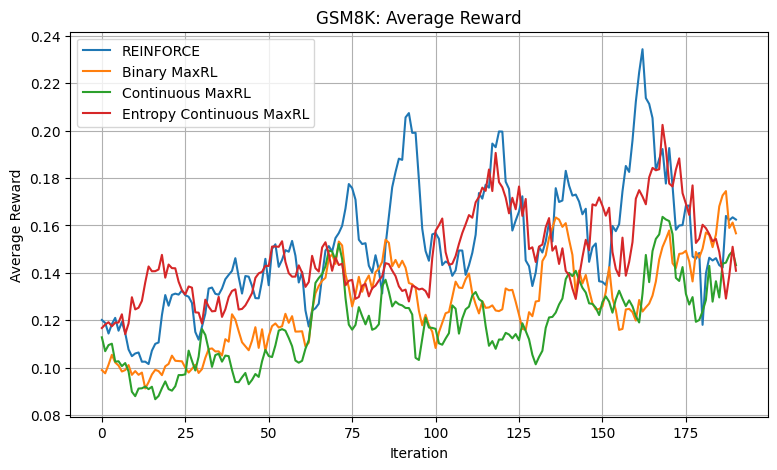

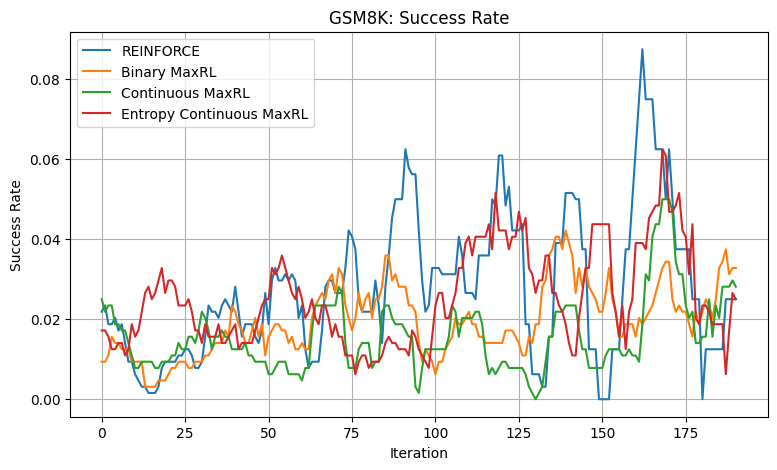

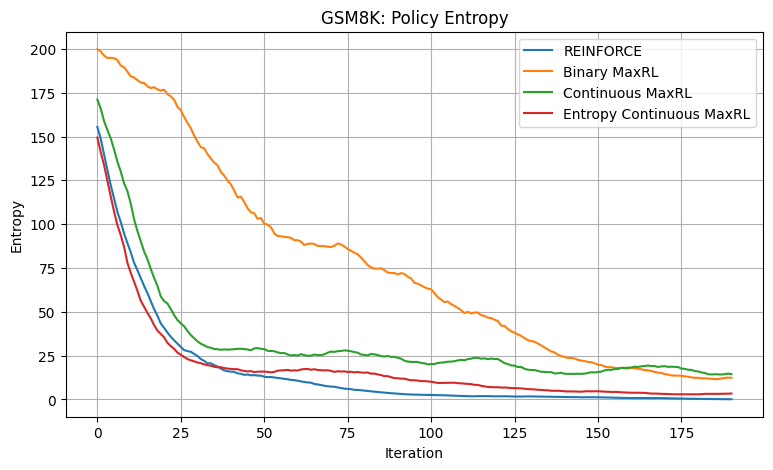

Figures saved to: /content/drive/MyDrive/maxrl_gsm8k/figures


In [ ]:
import matplotlib.pyplot as plt
import os

FIG_DIR = "/content/drive/MyDrive/maxrl_gsm8k/figures"
os.makedirs(FIG_DIR, exist_ok=True)

def moving_average(x, window=10):
    x = np.asarray(x)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode="valid")

plt.figure(figsize=(9, 5))
for name, hist in experiments_gsm8k.items():
    y = moving_average(hist["avg_reward"], window=10)
    plt.plot(y, label=name)
plt.xlabel("Iteration")
plt.ylabel("Average Reward")
plt.title("GSM8K: Average Reward")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(FIG_DIR, "gsm8k_avg_reward.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 5))
for name, hist in experiments_gsm8k.items():
    y = moving_average(hist["success_rate"], window=10)
    plt.plot(y, label=name)
plt.xlabel("Iteration")
plt.ylabel("Success Rate")
plt.title("GSM8K: Success Rate")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(FIG_DIR, "gsm8k_success_rate.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 5))
for name, hist in experiments_gsm8k.items():
    y = moving_average(hist["entropy"], window=10)
    plt.plot(y, label=name)
plt.xlabel("Iteration")
plt.ylabel("Entropy")
plt.title("GSM8K: Policy Entropy")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(FIG_DIR, "gsm8k_entropy.png"), dpi=300, bbox_inches="tight")
plt.show()

print("Figures saved to:", FIG_DIR)

In [ ]:
import shutil
from google.colab import files

ZIP_BASE = "/content/maxrl_gsm8k"
ZIP_PATH = ZIP_BASE + ".zip"

if os.path.exists(ZIP_PATH):
    os.remove(ZIP_PATH)

shutil.make_archive(ZIP_BASE, "zip", "/content/drive/MyDrive/maxrl_gsm8k")
files.download(ZIP_PATH)

# results

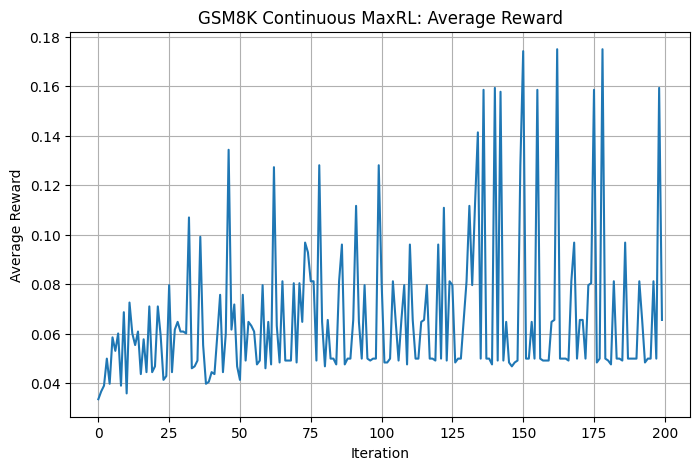

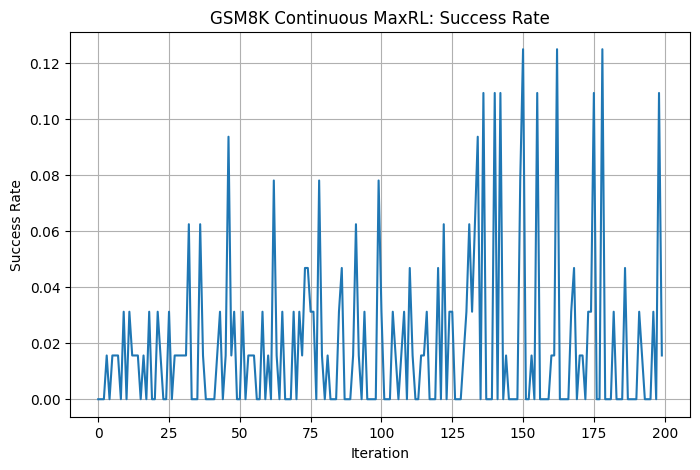

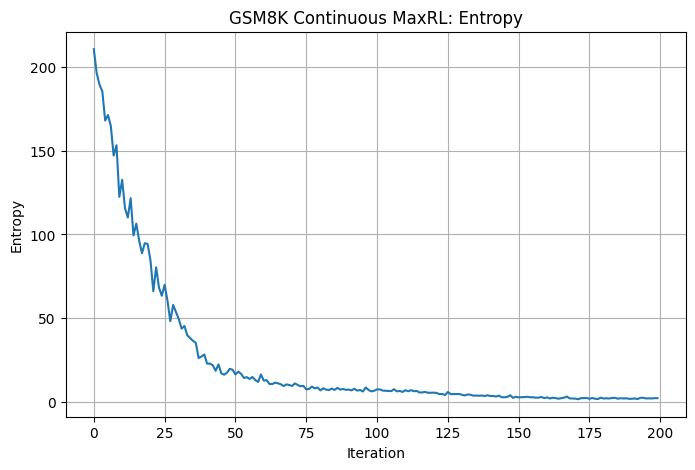

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(hist_cont["avg_reward"])
plt.xlabel("Iteration")
plt.ylabel("Average Reward")
plt.title("GSM8K Continuous MaxRL: Average Reward")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(hist_cont["success_rate"])
plt.xlabel("Iteration")
plt.ylabel("Success Rate")
plt.title("GSM8K Continuous MaxRL: Success Rate")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(hist_cont["entropy"])
plt.xlabel("Iteration")
plt.ylabel("Entropy")
plt.title("GSM8K Continuous MaxRL: Entropy")
plt.grid(True)
plt.show()

In [44]:
hist_cont.tail(10)

,avg_reward,success_rate,loss,entropy
190,0.050000,0.000000,-0.000103,2.062653
191,0.081250,0.031250,0.042159,2.231263
192,0.065625,0.015625,0.102746,1.909146
193,0.048437,0.000000,0.029880,2.632610
194,0.050000,0.000000,-0.000131,2.619043
195,0.050000,0.000000,-0.000112,2.239930
196,0.081250,0.031250,0.082571,2.308913
197,0.050000,0.000000,-0.000112,2.234231
198,0.159375,0.109375,0.032115,2.445225
199,0.065625,0.015625,0.102046,2.415649
